# XP Exercises - Inferential statistics with regression

As stated in the instructions, please complete the code when you see a "##TODO"


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_1samp


In [3]:
## TODO : load the dataset in a dataframe called d1, that you can find here : https://www.kaggle.com/code/youssefelzahar/inferential-statistics/input?select=air+traffic.csv
d1 = pd.read_csv('air traffic.csv')

# Columns Description

* Dom_Pax : Domestic Air Travel Passengers
* Int_Pax : International Air Travel Passengers
* Pax : Total Air Travel Passengers
* Dom_Flt : Number of Flights (Domestic)
* Int_Flt : Number of Flights (International)
* Flt : Number of Flights (Total)
* Dom_RPM : Revenue Passenger-miles (Domestic)
* Int_RPM : Revenue Passenger-miles (International)


In [4]:
## TODO: Check the summary of the DataFrame to see its structure and data types.
print(d1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    object 
 3   Int_Pax  249 non-null    object 
 4   Pax      249 non-null    object 
 5   Dom_Flt  249 non-null    object 
 6   Int_Flt  249 non-null    object 
 7   Flt      249 non-null    object 
 8   Dom_RPM  249 non-null    object 
 9   Int_RPM  249 non-null    object 
 10  RPM      249 non-null    object 
 11  Dom_ASM  249 non-null    object 
 12  Int_ASM  249 non-null    object 
 13  ASM      249 non-null    object 
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(3), int64(2), object(12)
memory usage: 33.2+ KB
None


In [7]:
print(d1.head())
print(d1.describe())

   Year  Month     Dom_Pax    Int_Pax         Pax  Dom_Flt Int_Flt      Flt  \
0  2003      1  43,032,450  4,905,830  47,938,280  785,160  57,667  842,827   
1  2003      2  41,166,780  4,245,366  45,412,146  690,351  51,259  741,610   
2  2003      3  49,992,700  5,008,613  55,001,313  797,194  58,926  856,120   
3  2003      4  47,033,260  4,345,444  51,378,704  766,260  55,005  821,265   
4  2003      5  49,152,352  4,610,834  53,763,186  789,397  55,265  844,662   

      Dom_RPM     Int_RPM         RPM     Dom_ASM     Int_ASM         ASM  \
0  36,211,422  12,885,980  49,097,402  56,191,300  17,968,572  74,159,872   
1  34,148,439  10,715,468  44,863,907  50,088,434  15,587,880  65,676,314   
2  41,774,564  12,567,068  54,341,633  57,592,901  17,753,174  75,346,075   
3  39,465,980  10,370,592  49,836,572  54,639,679  15,528,761  70,168,440   
4  41,001,934  11,575,026  52,576,960  55,349,897  15,629,821  70,979,718   

   Dom_LF  Int_LF     LF  
0   64.44   71.71  66.20  
1   68.1

# Inferential statistics

We will perform the following :

1. Linear Regression

2. Hypothesis testing




# Linear and Multiple Regression

The best linear line describe the correlation between two variables.

We have two types:

1. linear Regression
2. Multiple Regression

The equation of regression

**w=a+(b*x)**

**w=predict variable**(The point of intersection of the x axis and the y axis)

**a=intercept**(The point of intersection of the regression and the y axis)

**b=slope**(The amount of increase in regression relative to the x-axis)

# Linear Regression

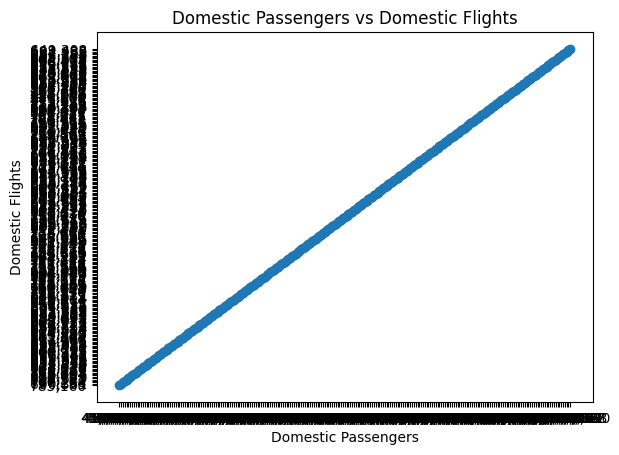

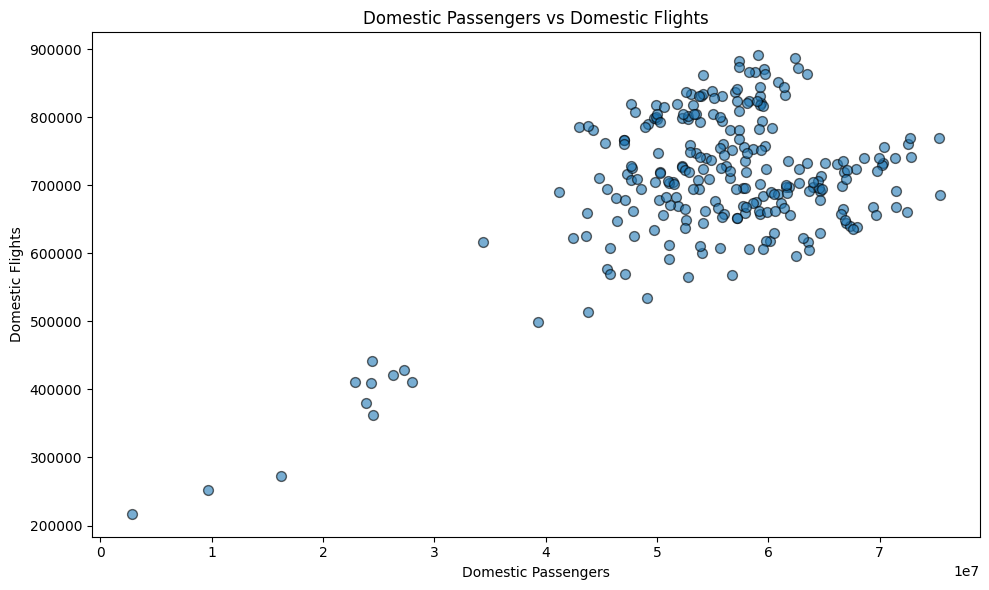

In [ ]:
## TODO: Explore the relationship between domestic passengers and domestic flights.
plt.scatter(d1['Dom_Pax'], d1['Dom_Flt'])
plt.xlabel('Domestic Passengers')
plt.ylabel('Domestic Flights')
plt.title('Domestic Passengers vs Domestic Flights')

dom_pax = d1['Dom_Pax'].str.replace(',', '').astype(int)
dom_flt = d1['Dom_Flt'].str.replace(',', '').astype(int)

plt.figure(figsize=(10, 6))
plt.scatter(dom_pax, dom_flt, alpha=0.6, edgecolor='k', s=50)
plt.xlabel('Domestic Passengers')
plt.ylabel('Domestic Flights')
plt.title('Domestic Passengers vs Domestic Flights')
plt.tight_layout()
plt.show()

Mean Squared Error: 8123249181.021609


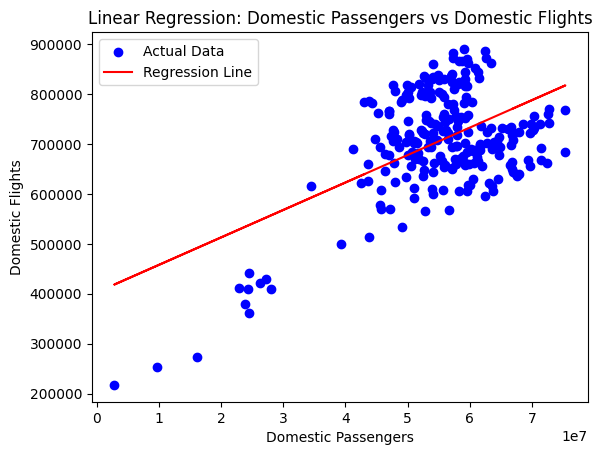

In [11]:
## TODO: Perform a linear regression between domestic passengers and domestic flights, and create a prediction model.
X = dom_pax.values.reshape(-1, 1)
y = dom_flt.values.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse}')
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('Domestic Passengers')
plt.ylabel('Domestic Flights')
plt.title('Linear Regression: Domestic Passengers vs Domestic Flights')
plt.legend()
plt.show()

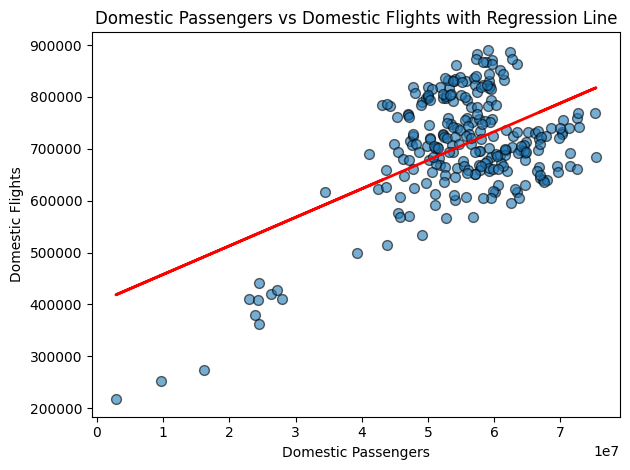

In [12]:
## TODO: Plot the scatter plot of domestic passengers versus domestic flights, and overlay the linear regression line.
plt.scatter(dom_pax, dom_flt, alpha=0.6, edgecolor='k', s=50)
plt.plot(dom_pax, y_pred, color='red', linewidth=2)
plt.xlabel('Domestic Passengers')
plt.ylabel('Domestic Flights')
plt.title('Domestic Passengers vs Domestic Flights with Regression Line')
plt.tight_layout()
plt.show()

In [13]:
## TODO: Print the slope, intercept, p-value, standard error, and the predicted value for 100 domestic passengers.
slope = model.coef_[0][0]
intercept = model.intercept_[0]
p_value = stats.linregress(dom_pax, dom_flt)[3]
std_error = np.std(y - y_pred)
predicted_value = model.predict(np.array([[100]]))[0][0]
print(f'Slope: {slope}')
print(f'Intercept: {intercept}')
print(f'P-value: {p_value}')
print(f'Standard Error: {std_error}')
print(f'Predicted value for 100 domestic passengers: {predicted_value}')

Slope: 0.005506132716515944
Intercept: 402758.7208295016
P-value: 5.3156895585332156e-20
Standard Error: 90129.06956704706
Predicted value for 100 domestic passengers: 402759.2714427732


# The coefficient of correlation

The relationship between the values on the x-axis and the y-axis determines whether linear regression can be used for prediction. If there is no relationship, linear regression is not suitable for making predictions.

The correlation coefficient (r) ranges from -1 to 1. A value of 0 indicates no relationship, while values close to 1 or -1 signify a strong positive or negative relationship, respectively, with a perfect correlation at either end.

In [14]:
## TODO: Print the slope, intercept, p-value, standard error, and the predicted value for 100 domestic passengers.
slope = model.coef_[0][0]
intercept = model.intercept_[0]
p_value = stats.linregress(dom_pax, dom_flt)[3]
std_error = np.std(y - y_pred)
predicted_value = model.predict(np.array([[100]]))[0][0]
print(f'Slope: {slope}')
print(f'Intercept: {intercept}')
print(f'P-value: {p_value}')
print(f'Standard Error: {std_error}')   
print(f'Predicted value for 100 domestic passengers: {predicted_value}')


Slope: 0.005506132716515944
Intercept: 402758.7208295016
P-value: 5.3156895585332156e-20
Standard Error: 90129.06956704706
Predicted value for 100 domestic passengers: 402759.2714427732


# Linear Regression


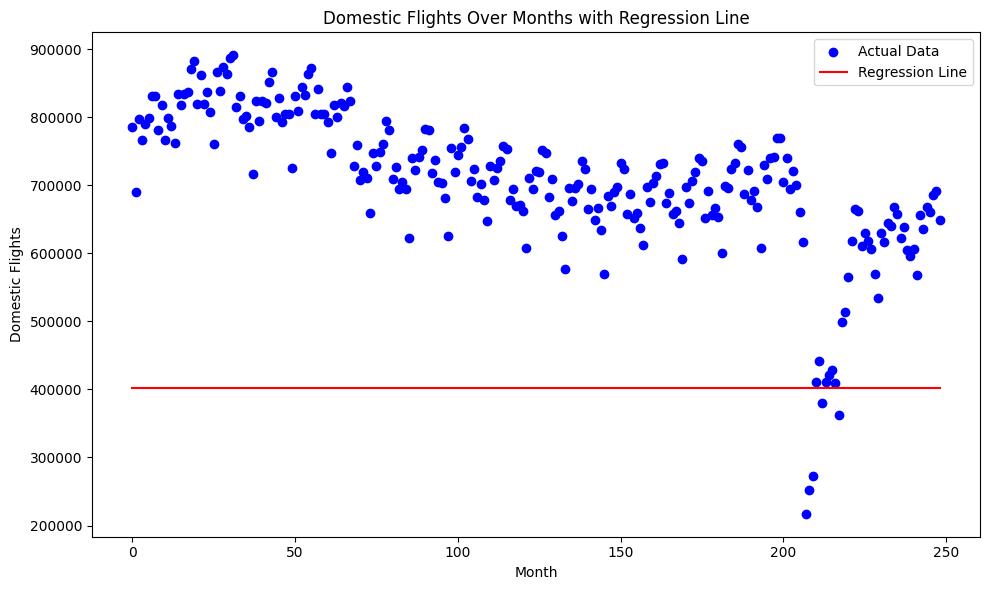

slope = 0.005506132716515946
intercept = 402758.72082950146
r² = 0.5369864170525395
p = 5.3156895585332156e-20
std_err = 0.000550385239973366


In [17]:
## TODO: Calculate linear regression parameters
slope, intercept, r2, p, std_err = stats.linregress(dom_pax, dom_flt)


## TODO:  Define the function for the linear model
def linear_model(x):
    return slope * x + intercept


## TODO:  Apply the model to the 'Month' data
months = np.arange(len(dom_pax))
predicted_flights = linear_model(months)


## TODO:  Plot the scatter plot and the regression line
plt.figure(figsize=(10, 6))
plt.scatter(months, dom_flt, color='blue', label='Actual Data')
plt.plot(months, predicted_flights, color='red', label='Regression Line')
plt.xlabel('Month')
plt.ylabel('Domestic Flights')
plt.title('Domestic Flights Over Months with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()

# Results
print("slope =", slope)
print("intercept =", intercept)
print("r² =", r2)
print("p =", p)
print("std_err =", std_err)


In [18]:
## TODO: Print r2
print(f'R-squared: {r2}')

R-squared: 0.5369864170525395


**Now Let's using ScikitLearn (Linear regression) to predict the value of y by using values of x**


In [19]:
## TODO: Prepare the data X and è for regression by reshaping the features using .reshape(-1,1)
X = dom_pax.values.reshape(-1, 1)
y = dom_flt.values.reshape(-1, 1)


In [20]:
## TODO: Split the data into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
## TODO: Fit the linear regression model, make a prediction, and evaluate the model.
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
print(f'Mean Squared Error on Validation Set: {mse}')

new_dom_pax = np.array([[60000000]])
predicted_dom_flt = model.predict(new_dom_pax)
print(f'Predicted Domestic Flights for 60,000,000 passengers: {predicted_dom_flt[0][0]}')

Mean Squared Error on Validation Set: 8029170325.715972
Predicted Domestic Flights for 60,000,000 passengers: 731970.1007815774


In [23]:
## TODO: Print the prediction for the given input.
print(f'Predicted Domestic Flights for 60,000,000 passengers: {predicted_dom_flt[0][0]}')

Predicted Domestic Flights for 60,000,000 passengers: 731970.1007815774


The Mean Squared Error (MSE) measures how well a regression line fits a set of data points by calculating the average of the squared differences between the observed values and the predicted values.

The formula for MSE is:

MSE=(1/n)*sum(yi-yhati)^2

yi=observed values

yhat=predict value

MSE quantifies the error between the observed and predicted values, with smaller values indicating better model accuracy.

In [24]:
## TODO: Calculate the mean squared error (MSE) for the training set.
mse_train = mean_squared_error(y_train, model.predict(X_train))
print(f'Mean Squared Error on Training Set: {mse_train}')


Mean Squared Error on Training Set: 8191556606.136429


What do you think ?

# Multiple Regression

Multiple regression is a statistical technique used to model the relationship between one dependent variable and two or more independent variables. This allows us to understand how multiple predictors influence a single outcome.

The general formula for multiple regression is:

y=β0+β1x1+β2x2+⋯+βpxp+ϵ


Where:

* y is the dependent (or response) variable,
* x1​,x2​,…,xp​ are the independent (predictor) variables,
* β0​ is the intercept,
* pβ1​,β2​,…,βp​ are the regression coefficients for each independent variable,
* ϵ is the error term.

the goal is to estimate the coefficients (β) that minimize the error between the predicted and actual values of the dependent variable.

T-statistic: [104.17393932], P-value: [1.00019632e-206]


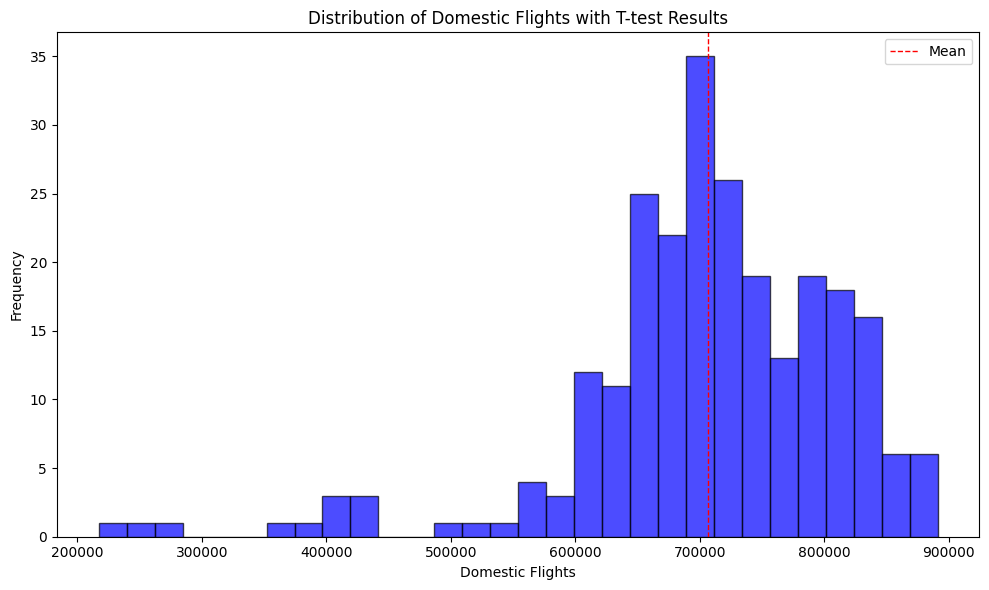

In [26]:
## TODO: Reshape the features mx and target variables my .
mx = dom_pax.values.reshape(-1, 1)
my = dom_flt.values.reshape(-1, 1)
# Perform a t-test to check if the mean of domestic flights is significantly different from 0
t_statistic, p_value = ttest_1samp(my, 0)
print(f'T-statistic: {t_statistic}, P-value: {p_value}')
# Plotting the t-test results
plt.figure(figsize=(10, 6))
plt.hist(my, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(np.mean(my), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.title('Distribution of Domestic Flights with T-test Results')
plt.xlabel('Domestic Flights')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
## TODO: Split the features and target variables into training and validation sets.
X_train, X_val, y_train, y_val = train_test_split(mx, my, test_size=0.2, random_state=42)


R^2 Score on Training Data: 0.33257787288949936


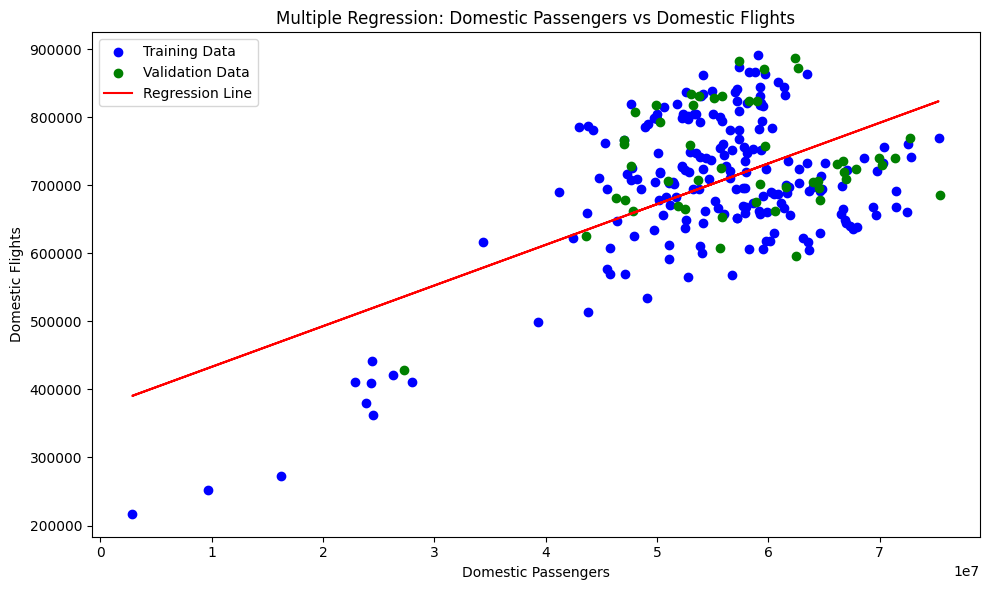

In [28]:
## TODO: Fit the multiple regression model and calculate the R^2 score on the training data using .score
model = LinearRegression()
model.fit(X_train, y_train)
r2_train = model.score(X_train, y_train)
print(f'R^2 Score on Training Data: {r2_train}')
# Plotting the regression line for multiple regression
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_val, y_val, color='green', label='Validation Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')
plt.xlabel('Domestic Passengers')
plt.ylabel('Domestic Flights')
plt.title('Multiple Regression: Domestic Passengers vs Domestic Flights')
plt.legend()
plt.tight_layout()  
plt.show()

In [29]:
## TODO: Print the target values
print(f'Target Values (Domestic Flights): {y_train.flatten()}')


Target Values (Domestic Flights): [624812 636761 410189 670793 723997 844737 408807 651176 662154 690116
 644024 659785 694712 694852 719340 634734 667331 647027 600492 640218
 659899 610284 753441 728856 622299 694749 863422 751473 781315 739894
 798351 805066 732292 732753 441615 815914 741462 721429 379506 669783
 890938 787237 802067 872961 852114 657576 820048 737224 645169 756675
 809663 702581 648891 768645 748984 820310 735084 629670 793994 683892
 866593 605944 652003 605075 695855 785160 797194 760136 792523 743778
 747070 569018 656939 782439 622999 691482 688347 754669 785364 746679
 673171 693925 798392 636160 838122 658392 789397 710137 814935 666264
 691971 735424 817511 676337 683379 630240 655836 707246 617735 820114
 799777 499359 824051 693876 687710 836232 759879 698464 726573 794390
 252450 805058 704372 700493 713634 866551 569972 696983 766260 723222
 832163 577191 617806 667538 616135 724657 731988 709793 797460 660344
 830737 673380 728636 781423 704840 664437 

In [30]:
## TODO: Make a prediction using the multiple regression model.
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
print(f'Predictions on Training Set: {y_pred_train.flatten()}')
print(f'Predictions on Validation Set: {y_pred_val.flatten()}')

Predictions on Training Set: [659992.58476625 686986.98108993 540868.30150751 679166.93860364
 730528.5576453  740346.59806844 518627.47236151 714938.94754185
 727058.18775335 733475.94931951 773580.07073773 719240.99624546
 694791.70479711 645314.82155257 719961.25977762 670572.95410093
 800248.06290771 650714.83762253 696574.06237832 776011.85968129
 634410.65398993 695528.00433564 723879.20339365 685621.68518935
 750735.33623035 663742.85260033 730320.842651   727848.90093411
 711458.47669918 698643.40052097 685407.20435114 685995.92242507
 793399.02660719 762622.76858817 519379.59273824 729335.31261302
 808413.95836051 711427.09202923 515931.92308939 718211.55396787
 726654.44856926 635236.94762018 688944.09109549 715975.19152472
 736982.35988177 770939.8495726  682850.19350313 701045.95049948
 696758.61690869 718693.62034675 716408.2294428  678634.77987684
 687607.99829859 823304.54083589 689824.52343083 727769.06756206
 719438.30546745 759565.5933265  728796.11310519 729323.69950

# Hypothesis testing

Hypothesis testing is a systematic procedure used to evaluate whether the results of a research study support a particular theory or assumption about a population. It helps determine if there is enough evidence to reject or fail to reject a hypothesis based on sample data.

**we have two types**

1. The null hypothesis H0, represents the idea that there is no effect, relationship, or difference in the population. It serves as the baseline assumption that any observed effect in the data is due to chance.

Example: "There is no significant difference in test scores between two groups."

2. The alternative hypothesis Ha suggests that there is an effect, relationship, or difference in the population. It is what researchers typically aim to support with their data.

Example: "There is a significant difference in test scores between two groups."

In hypothesis testing, we aim to gather enough evidence from the sample to either reject the null hypothesis (H0H0​) in favor of the alternative hypothesis (HaHa​), or fail to reject the null hypothesis, indicating that there isn't sufficient evidence for the alternative hypothesis.


# Null hypothesis

The null hypothesis (H0H0​) is a statement that there is no significant difference or effect in the population. It assumes that any observed differences in the sample are due to random chance.

In hypothesis testing, the decision to reject or fail to reject the null hypothesis is based on the p-value.

If :
* p ≤ 0.05: Reject H0H0​ (evidence supports HaHa​).
* p > 0.05: Fail to reject H0H0​ (no evidence to support HaHa​).

# Alternative hypothesis Ha

The alternative hypothesis (HaHa​) is a statement in statistical hypothesis testing that suggests there is a significant difference, effect, or relationship in the population, contrary to the null hypothesis (H0H0​).

In other words, HaHa​ proposes that the observed data is not due to random chance, and there is some true effect or difference in the population that can be detected.

For example:

- Null Hypothesis (H0​): There is no significant difference in test scores between two groups.
- Alternative Hypothesis (Ha​): There is a significant difference in test scores between the two groups.

The goal of hypothesis testing is to gather enough evidence to reject the null hypothesis in favor of the alternative hypothesis, suggesting that the observed effect or difference is statistically significant.

T-statistic: [88.89391911], P-value: [1.54003874e-161]


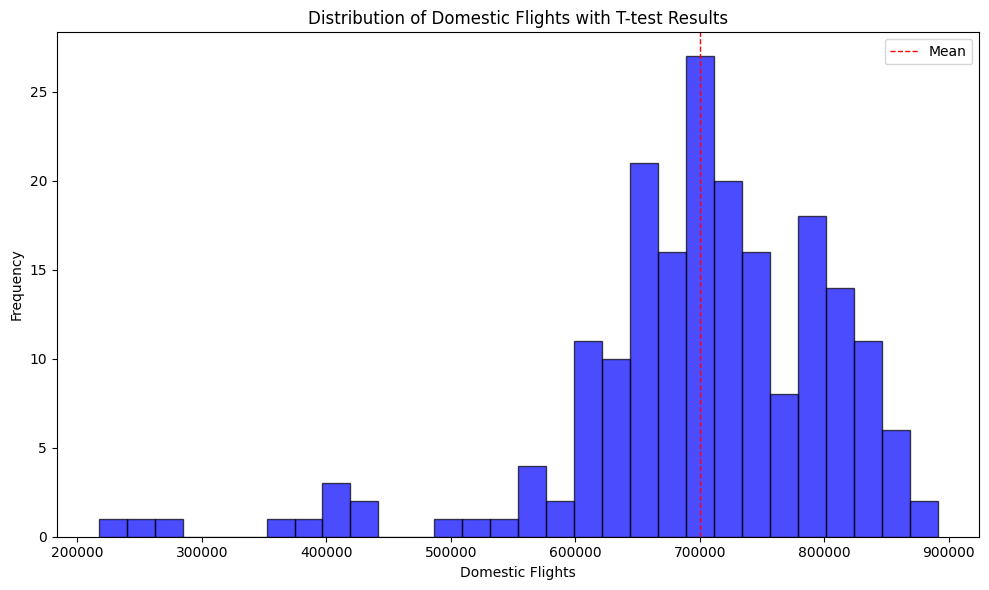

In [31]:
## (Optional) TODO: Perform hypothesis testing for two variables of your choice
# Example: Perform a t-test to check if the mean of domestic flights is significantly different from 0
t_statistic, p_value = ttest_1samp(y_train, 0)
print(f'T-statistic: {t_statistic}, P-value: {p_value}')
# Plotting the t-test results
plt.figure(figsize=(10, 6))
plt.hist(y_train, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(np.mean(y_train), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.title('Distribution of Domestic Flights with T-test Results')
plt.xlabel('Domestic Flights')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# One sample test

is used to compare the diffrence between sample and population mean

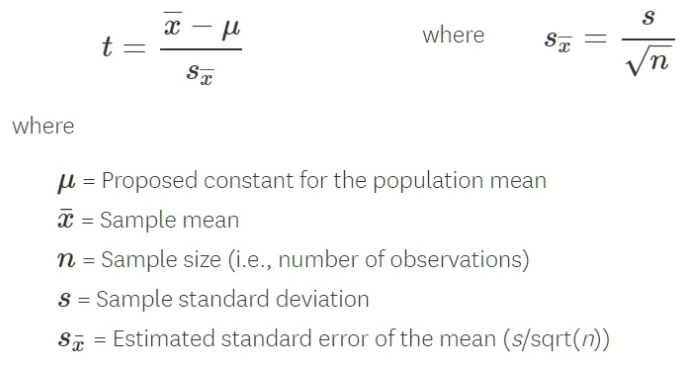

In [32]:
## TODO: Calculate the population mean of the "Year" column.
population_mean_year = d1['Year'].mean()
print(f'Population Mean of Year: {population_mean_year}')

Population Mean of Year: 2012.879518072289


In [33]:
# let's take sample from data

sample=np.random.choice(d1["Year"],50)

In [34]:
sample

array([2004, 2016, 2015, 2012, 2012, 2019, 2011, 2020, 2017, 2006, 2020,
       2021, 2014, 2014, 2016, 2022, 2020, 2008, 2018, 2012, 2015, 2013,
       2008, 2016, 2013, 2017, 2014, 2004, 2005, 2021, 2004, 2019, 2012,
       2017, 2019, 2017, 2011, 2013, 2014, 2005, 2012, 2005, 2018, 2019,
       2014, 2009, 2021, 2006, 2007, 2004], dtype=int64)

In [36]:
## Perform a one-sample t-test to compare the sample mean with the population mean.
popmean = population_mean_year
from scipy.stats import ttest_1samp

ttest,p_value=ttest_1samp(sample,popmean)


In [37]:
ttest

0.6528649804607196

In [38]:
sample.mean()

2013.38

In [39]:
## TODO: Perform hypothesis testing based on the p-value.
if p_value < 0.05:
    print("Reject the null hypothesis: The sample mean is significantly different from the population mean.")
else:
    print("Fail to reject the null hypothesis: The sample mean is not significantly different from the population mean.")

Fail to reject the null hypothesis: The sample mean is not significantly different from the population mean.


# Two sample test

it is a statistical test used to compare the means of two independent groups to determine if there is a statistically significant difference between them. It is commonly employed when researchers want to assess whether the mean values of a particular variable differ between two distinct groups.

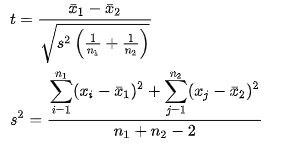

In [40]:
## TODO: Randomly select a sample of 50 from the "Flt" column.
sample = np.random.choice(d1['Flt'], 50)
print(f'Sample of 50 Domestic Flights: {sample}')

Sample of 50 Domestic Flights: ['809,686' '628,345' '905,715' '813,081' '951,311' '745,517' '921,981'
 '795,925' '788,704' '740,518' '768,619' '867,307' '776,504' '708,118'
 '815,270' '628,054' '941,286' '940,939' '801,999' '961,902' '670,514'
 '711,905' '867,307' '827,637' '719,555' '679,388' '940,939' '610,401'
 '905,715' '751,454' '740,629' '767,933' '822,246' '467,620' '788,620'
 '819,535' '679,597' '778,423' '864,080' '433,913' '895,946' '854,346'
 '856,576' '855,970' '820,663' '817,127' '768,040' '941,286' '740,629'
 '719,062']


In [41]:
## TODO: Randomly select a sample of 50 from the "Dom_Pax" column.
sample_dom_pax = np.random.choice(d1['Dom_Pax'], 50)
print(f'Sample of 50 Domestic Passengers: {sample_dom_pax}')


Sample of 50 Domestic Passengers: ['58,286,011' '55,088,983' '50,253,658' '57,870,281' '55,486,727'
 '61,757,222' '63,498,165' '59,688,267' '72,715,566' '57,145,193'
 '57,150,501' '57,084,257' '52,801,276' '47,348,142' '68,574,097'
 '53,030,873' '2,877,290' '57,888,637' '34,413,597' '54,332,936'
 '59,758,814' '56,568,180' '43,032,450' '44,821,711' '55,649,428'
 '53,691,455' '48,584,832' '55,679,100' '66,520,067' '50,304,708'
 '58,893,676' '43,677,233' '24,431,273' '51,076,415' '59,534,619'
 '54,424,077' '51,111,121' '64,659,493' '59,213,077' '63,518,318'
 '50,982,170' '56,568,180' '63,518,318' '58,646,304' '56,959,142'
 '48,886,043' '55,828,555' '54,167,489' '43,798,512' '61,708,696']


In [43]:
## TODO: Perform an independent t-test between `sample_a` and `sample_b` to compare their means.
# Remove commas and convert to integers
sample_a_clean = np.array([int(x.replace(',', '')) for x in sample_a])
sample_b_clean = np.array([int(x.replace(',', '')) for x in sample_b])

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(sample_a_clean, sample_b_clean, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: -35.869987074458784, P-value: 7.744994797972278e-37


In [44]:
if p_value <=0.05:
    print("rejected null hypothesis",p_value)
else:
    print("accepted null hypothesis",p_value)

accepted null hypothesis 0.5168948932170176


# Type| & Type ||

Reject the null hypothesis when it’s actually true (Type I error)

Reject the null hypothesis when it’s actually false (Correct)

Fail to reject the null hypothesis when it’s actually true (Correct)

Fail to reject the null hypothesis when it’s actually false (Type II error)

![](https://miro.medium.com/v2/resize:fit:828/format:webp/0*JM4fxEI__jX5f4Oy)